
# OUTDATED - SEE v9.py AND COPY/FORMAT CONTENTS TO HERE; PNGs MAY BE LOADED INTO HERE IN PLACE OF IPOPT

---

# Training on step tests (demo)



In [52]:
from FoKL import FoKLRoutines
import os
dir = os.path.abspath('')  # directory of notebook
# -----------------------------------------------------------------------
# UNCOMMENT IF USING LOCAL FOKL PACKAGE:
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
# -----------------------------------------------------------------------
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae

In [35]:
# System-level parameters:

Tamb = 21  # ambient temperature (C)
Tmax = 140  # maximumum temperature, i.e., steady state of u=100 (C)
t0 = 0  # start time (s)
dt = 1  # time step (s)
t_ramp = 800  # estimated time to reach steady state (s)
t_rest = 200  # time to "rest" at steady state for sake of obtaining dT=0 training data
t_drop = 400  # estimated time to return to Tamb (s)
n = 10  # number of step tests to obtain data for

DATA GENERATION:

Because heat transfer, natural log relationship is expected between heat and temperature.

Asymptotes of natural log cannot be "shrunk" to be made to look natural; quadratic with exact heigh peak visually looks more natural when transitioning into steady state.

However, time derivative of quadratic produces linear which is not realistic. Time derivative of step test data looks like derivative of natural log.

Taking log of quadratic satisfies both asymptotes and derivative.

$$y_1 = Q = H (1 - (\frac{x + W}{W} - 1)^2) \equiv \text{ quadratic}$$

$$y_2 = L = \ln(Q) \cdot \frac{H}{\ln(H)} \equiv \text{ log of quad}$$

To ensure $L$ is adjusted properly to maintain the same horizontal intercept, since $y_2=0$ is now misaligned from $y_1=0$,

$$0 = Q(x_1) = L(x_2) \implies H (1 - (\frac{x_1 + W}{W} - 1)^2) = \ln(H (1 - (\frac{x_2 + W}{W} - 1)^2)) \cdot \frac{H}{\ln(H)}$$

$$\implies \delta \equiv x_1 - x_2 = W \cdot (1 - \sqrt{1 - H^{-1}})$$

The properly adjusted log of quadratic equation is then

$$y_3 = L' = \ln(Q') \cdot \frac{H}{\ln(H)}$$

But $W$ is the correct width for $Q$ not $L$ and so it must be redefined $W' = \frac{W}{\sqrt{1-H^{-1}}}$ such that it drives $L'$ to maintain the same horizontal intercept as original $Q$.

$$Q' = H (1 - (\frac{x + W'}{W'} - 1)^2)$$

Adjusting $x$ so that the horizontal intercept passes through the origin; that is, $y_3(0)=0$,

$$Q' = H (1 - (\frac{x - W + W'}{W'} - 1)^2)$$

In [44]:
# Generate data for demonstration:

u1_tests = np.linspace(100 / n, 100, n)  # heater power (%), const. values at which to obtain data
T_tests = np.linspace(Tamb + (Tmax - Tamb) / n, Tmax, n)  # steady state temperature corresponding to u1_tests

t_seg = t_ramp + t_rest + t_drop + t_rest / n  # length of single test
tf = t0 + n * t_seg
tvec = np.linspace(t0, tf, int((tf + 1) / dt))
dt = tvec[1] - tvec[0]  # redefine in case dt got rounded

u = np.zeros_like(tvec)
T = np.zeros_like(tvec) + Tamb

def T_approx(t_start, t_end, i):
    """Estimate temperature change using natural log of quadratic."""
    x = tvec[t_start:t_end] - tvec[t_start]
    H = T_tests[i] - Tamb
    W = t_end - t_start
    
    W0 = W / np.sqrt(1 - 1 / H)                 # == W'
    Q = H * (1 - ((x - W + W0) / W0 - 1) ** 2)  # == Q'
    L = np.log(Q) * H / np.log(H)               # == L'
    
    return L

t1 = int(t0)
for i in range(n):
    t2 = int(t1 + t_ramp)
    t3 = int(t1 + t_ramp + t_rest)
    t4 = int(t1 + t_ramp + t_rest + t_drop)
    
    T[t1:t2] = Tamb + T_approx(t1, t2, i)        # ramp up
    T[t2:t3] = T_tests[i]                        # steady state
    T[t3:t4] = T_tests[i] - T_approx(t3, t4, i)  # drop

    u[t1:t3] = u1_tests[i]  # const.

    t1 = int(t1 + t_seg)

In [45]:
def gradient_h4(x, h):
    """h is step size. Order of error is h^4."""
    dx = np.zeros_like(x)

    # bleed in:
    h2 = 2 * h
    dx[0] = (x[1] - x[0]) / h
    dx[1] = (x[2] - x[0]) / h2

    # center difference:
    h12 = 12 * h
    for i in range(2, x.shape[0] - 2):
        dx[i] = (x[i - 2] - 8 * x[i - 1] + 8 * x[i + 1] - x[i + 2]) / h12
    
    # bleed out:
    dx[-2] = (x[-1] - x[-3]) / h2
    dx[-1] = (x[-1] - x[-2]) / h

    return dx

dT = gradient_h4(T, dt)
dTf = interp1d(tvec, dT, kind='previous')  # piecewise, grab previous value

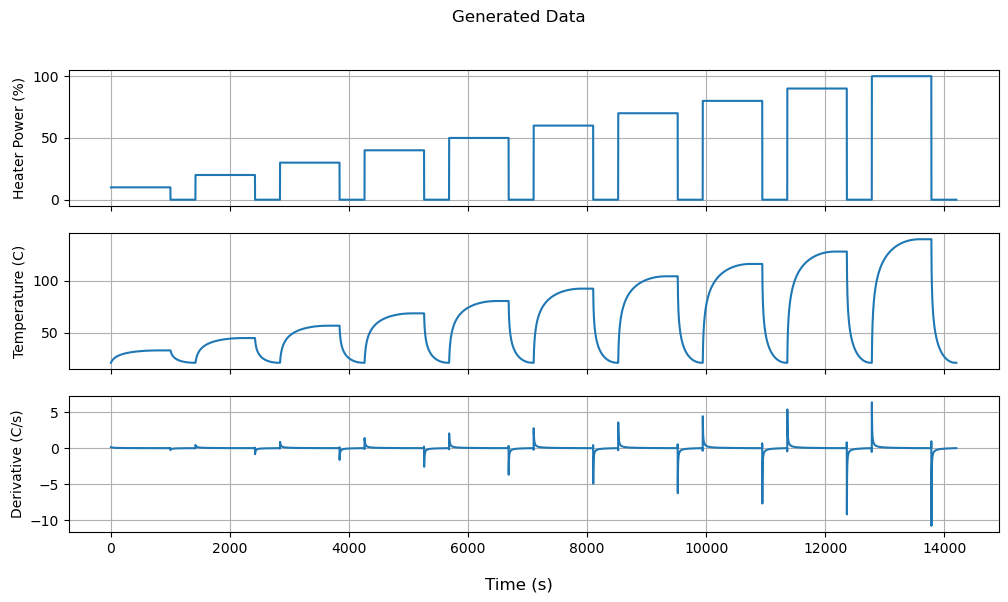

In [46]:
fig, ax = plt.subplots(3, sharex=True, figsize=(12, 6))
fig.suptitle("Generated Data")
fig.supxlabel("Time (s)")

ax[0].set_ylabel("Heater Power (%)")
ax[0].plot(tvec, u)

ax[1].set_ylabel("Temperature (C)")
ax[1].plot(tvec, T)

ax[2].set_ylabel("Derivative (C/s)")
ax[2].plot(tvec, dT)

for i in range(len(ax)):
    ax[i].grid()

In [47]:
GP = FoKLRoutines.FoKL(kernel=1)
_ = GP.fit([T, u], dT, clean=True)

/home/jacobpatrick/ESMS/dev/tclab/examples/pyomo_tclab/../../src/FoKL/FoKLRoutines.py:290: UserWarning: 'inputs' was transposed. Ignore if more datapoints than input variables, else set 'AutoTranspose=False' to disable.
  warnings.warn("'inputs' was transposed. Ignore if more datapoints than input variables, else set "


[1, -29487.6190403933]
[2, -30079.263593870277]
[2, -31318.06881132543]
[3, -44194.79487816826]
[3, -49788.835307884015]
[4, -49821.14676097397]
[4, -50514.10491459213]
[4, -51205.33229264113]
[5, -51201.2805027563]
[5, -51855.37046683016]
[5, -52728.345335248225]
[6, -52730.51291415148]
[6, -52947.161523159855]
[6, -52931.321038787755]
[6, -52918.62847453376]
[7, -52962.09929836197]
[7, -52973.42430193436]
[7, -53740.08454837081]
[7, -54222.172386832106]
[8, -54220.86805463865]
[8, -54249.23977042653]
[8, -54236.064476269865]
[8, -54321.88775566809]
[8, -54448.76053701644]
[9, -54463.512348043674]
[9, -54454.17212036634]
[9, -54468.16679359524]
[9, -54675.118274013934]
[9, -54880.59495020513]
[10, -54880.59495020513]
[10, -54880.59495020513]
[10, -54882.88310143936]
[10, -54882.6621342766]
[10, -54950.32342016991]
[10, -55083.05116075531]
[11, -55083.05116075531]
[11, -55083.05116075531]
[11, -55078.63612531889]


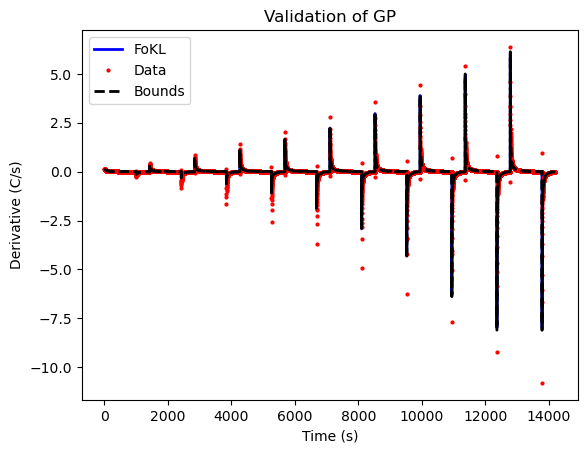

In [51]:
_ = GP.coverage3(plot=True, title="Validation of GP", xlabel="Time (s)", ylabel="Derivative (C/s)")

In [53]:
# =====================================================================
# =====================================================================
# CONTROLLER REFERENCE TRAJECTORY:

# time grid
t0 = 0
tf = 999
dt = 1
n = round(tf / dt)
tvec = np.linspace(t0, tf, n + 1)

# ambient temperature
Tamb = 21

# time points of setpoint/reference values
tr = [t0, 50, 150, 450, 550, tf]

# setpoint/reference
def r(t):
    return np.interp(t, tr, [Tamb, Tamb, 60, 60, 35, 35])

# derivative of setpoint/reference
dr_interp = interp1d(tr, [0, (60 - Tamb) / 100, 0, (35 - 60) / 100, 0, 0], kind='previous')
def dr(t):
    return float(dr_interp(t))

# =====================================================================
# =====================================================================
# OPTIMIZATION USING GP MODEL - CREATION OF PYOMO MODEL:

# Create a Pyomo model
m = pyo.ConcreteModel('TCLab Heater with GP Model')

# Define time domain
m.t = dae.ContinuousSet(bounds=(t0, tf))

# Define the state variables as a function of time
m.Ts1 = pyo.Var(m.t)

# Define the control variable (heater power) as a function of time
m.u1 = pyo.Var(m.t, bounds=(0, 100))

# Define the derivatives of the state variables
m.dTs1 = dae.DerivativeVar(m.Ts1, wrt=m.t)

# Fix the initial conditions
m.Ts1[t0].fix(Tamb)

# Arguments to embed GP in Pyomo model:
xvars = [m.Ts1, m.u1]
yvar = m.dTs1
draws = 5

# Embed GP:
GP.to_pyomo(xvars, yvar, m, draws, with_blocks=False)

Ipopt 3.14.16: linear_solver=ma27

Exception of type: DYNAMIC_LIBRARY_FAILURE in file "Common/IpLibraryLoader.cpp" at line 86:
 Exception message: libhsl.so: cannot open shared object file: No such file or directory

EXIT: Library loading failure.
model.name="TCLab Heater with GP Model";
    - termination condition: other
    - message from solver: <undefined>
ERROR: evaluating object as numeric value: u1[0]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized NumericValue object u1[0]


ValueError: No value for uninitialized NumericValue object u1[0]

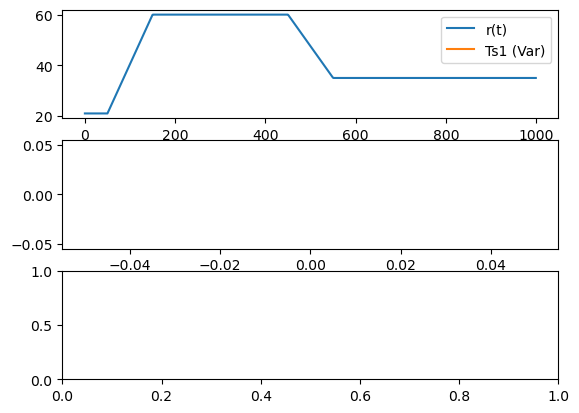

In [54]:
# =====================================================================
# =====================================================================
# OPTIMIZATION USING GP MODEL - SOLVE WITH IPOPT:

# Define the error model
@m.Integral(m.t)
def ise(m, t):
    return (r(t) - m.Ts1[t]) ** 2

# Define the objective function
@m.Objective(sense=pyo.minimize)
def objective(m):
    return m.ise

# Apply a collocation method to numerically integrate the differential equations
pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=100, wrt=m.t)

# Call our nonlinear optimization/equation solver, Ipopt
solver = pyo.SolverFactory('ipopt')
solver.options['linear_solver'] = 'ma27'  # ma57
solver.solve(m, tee=True)

# Plot solution

tvec = m.t.data()

fig, axs = plt.subplots(3)

axs[0].plot()
axs[0].plot(tvec, r(tvec))
axs[0].plot(tvec, m.Ts1[:]())
axs[0].legend(['r(t)', 'Ts1 (Var)'])

axs[1].plot(tvec, m.dTs1[:]())
axs[1].plot(tvec, m.y_avg[:]())
axs[1].plot(tvec, GP.evaluate([m.Ts1[:](), m.u1[:]()], clean=True))  # GP confirmation
axs[1].legend(['dTs1 (Var)', 'm.y_avg', 'dTs1 (GP check)'])

# axs[2].plot(u1_benchmark[:, 0], u1_benchmark[:, 1])
axs[2].plot(tvec, m.u1[:]())
axs[2].legend(['u1 (benchmark)', 'u1 (Var)'])

for i in range(3):
    axs[i].grid()

plt.show()